# IY021 – SVM vs Catch22+SVM on ALL Experimental Time Series

**Goal:** Same analysis as `IY021_catch22_svm_exp_data.ipynb` but including all experiments with
clear carbon-source labels from `EXP-25-IY008/4_transformed_exp_time_series/`.

**Environments (labels) — verified via `get_exp_summary`:**
- `0` — 2% glucose (experiments 19316, 18589, 19330)
- `1` — 0.1% glucose (experiments 19566, 18446, 19394)
- `2` — 0.01% glucose (experiments 19554, 20213)
- `3` — 2% galactose (experiment 19391 — pump: 2% raffinose -> 2% galactose)
- `4` — 0.01% galactose (experiment 19392 — pump: 2% glucose -> 0.01% galactose)

**Excluded experiments:**
- `18360` — no explicit carbon source concentration in filename ("2min" refers to interval)
- `18464` — mock condition (not a carbon source concentration)

**Length handling:** Different experiments have different numbers of timepoints.
- Raw SVM: all series truncated to the global minimum timepoints across loaded files
- Catch22 + SVM: features extracted from full-length series (Catch22 is length-agnostic)

**Data source:** `EXP-25-IY008/4_transformed_exp_time_series/`

In [11]:
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
from pathlib import Path
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

RANDOM_STATE = 42
IY021_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY021")
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
np.random.seed(RANDOM_STATE)
sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. Load Data & Assign Environment Labels

In [12]:
# Verify experimental conditions using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_EXPERIMENT_OMIDS = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "18589": "18589_2020_02_10_steadystate_glucose_898S_2w2_01",
    "19330": "19330_2020_11_02_steadystate_glucose_1345m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "18446": "18446_2020_01_08_steadystate_glucose_2w0p1_2min_01",
    "19394": "19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
    "19391": "19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00",
    "19392": "19392_2020_11_12_steadystate_glucose_898m_2w0p01_00",
}

print("Experimental condition verification via get_exp_summary")
print("=" * 70)
for prefix, omid in _EXPERIMENT_OMIDS.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump_contents = summary_df["pump_contents"].values[0]
    omero_tags    = summary_df["omero_tags"].values[0]
    switch_times  = summary_df["switch_times"].values[0]
    print(f"\n{prefix}  ({omid[:60]})")
    print(f"  Pump contents : {pump_contents}")
    print(f"  Switch times  : {switch_times}  (steady-state condition = pump 2)")
    print(f"  OMERO tags    : {omero_tags}")

print("\n")
print("Label assignments (from acquisition file pump contents):")
print("  19316, 18589, 19330  -> label 0 : 2% glucose      (both pumps = 2% glucose)     OK")
print("  19566, 18446, 19394  -> label 1 : 0.1% glucose    (pump 2 = 0.1% glucose)       OK")
print("  19554, 20213         -> label 2 : 0.01% glucose   (pump 2 = 0.01% glucose)      OK")
print("  19391                -> label 3 : 2% galactose    (pump 2 = 2% galactose)       OK")
print("  19392                -> label 4 : 0.01% galactose (pump 2 = 0.01% galactose)    OK")
print("  (Note: OMERO tags for 19391 and 19392 incorrectly say '0.01% glucose';")
print("   acquisition file pump contents are used as ground truth.)")

Experimental condition verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORM

In [13]:
# Map experiment ID prefix to carbon-source environment label
# Verified via get_exp_summary (see cell above) — labels based on pump 2 (steady-state condition):
#   19391: pump = ['2% raffinose in SC', '2% galactose in SC']  -> 2% galactose
#   19392: pump = ['2% glucose in SC', '0.01% galactose in SC'] -> 0.01% galactose
#   (OMERO tags for 19391 and 19392 incorrectly say '0.01% glucose')
EXPERIMENT_LABELS = {
    # 2% glucose (both pumps = 2% glucose in SC)
    "19316": (0, "2% glucose"),
    "18589": (0, "2% glucose"),
    "19330": (0, "2% glucose"),
    # 0.1% glucose (pump 2 = 0.1% glucose in SC)
    "19566": (1, "0.1% glucose"),
    "18446": (1, "0.1% glucose"),
    "19394": (1, "0.1% glucose"),
    # 0.01% glucose (pump 2 = 0.01% glucose in SC)
    "19554": (2, "0.01% glucose"),
    "20213": (2, "0.01% glucose"),
    # 2% galactose (pump 1 = 2% raffinose, pump 2 = 2% galactose in SC)
    "19391": (3, "2% galactose"),
    # 0.01% galactose (pump 1 = 2% glucose, pump 2 = 0.01% galactose in SC)
    "19392": (4, "0.01% galactose"),
}

META_COLS = ["id", "group", "experiment"]
label_names = {
    0: "2% glucose",
    1: "0.1% glucose",
    2: "0.01% glucose",
    3: "2% galactose",
    4: "0.01% galactose",
}

all_ts_raw = []   # list of (n_cells, n_timepoints) arrays — variable T per file
all_y = []

csv_files = sorted(DATA_DIR.glob("*.csv"))
for csv_path in csv_files:
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        print(f"Skipping (no label):     {csv_path.name[:70]}")
        continue

    # Skip the 19316 _mCherry_mCherry file (same cells as _mCherry, different recording window)
    if "_mCherry_mCherry_" in csv_path.name:
        print(f"Skipping (duplicate):    {csv_path.name[:70]}")
        continue

    label, env_name = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)

    time_cols = [c for c in df.columns if c not in META_COLS]
    ts_matrix = df[time_cols].values.astype(float)  # (n_cells, n_timepoints)

    all_ts_raw.append(ts_matrix)
    all_y.extend([label] * len(ts_matrix))
    print(f"  {csv_path.name[:65]}")
    print(f"    -> label={label} ({env_name}), {ts_matrix.shape[0]} cells x {ts_matrix.shape[1]} timepoints")

# Determine common (minimum) number of timepoints
min_T = min(ts.shape[1] for ts in all_ts_raw)
print(f"\nTimepoints per file: {[ts.shape[1] for ts in all_ts_raw]}")
print(f"Global minimum: {min_T} timepoints -- all series will be truncated to this length for Raw SVM")

# Truncated dataset (for Raw SVM)
X_raw = np.vstack([ts[:, :min_T] for ts in all_ts_raw])  # (N, min_T)
y     = np.array(all_y, dtype=int)

print(f"\nFull dataset: {X_raw.shape[0]} cells x {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y == lbl)} samples")

Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_1106_GFP_time_serie
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_1106_mCherry_time_s
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_898_GFP_time_series
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_898_mCherry_time_se
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_900_GFP_time_series
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_900_mCherry_time_se
  18446_2020_01_08_steadystate_glucose_2w0p1_2min_01_group_po_GFP_t
    -> label=1 (0.1% glucose), 744 cells x 158 timepoints
  18446_2020_01_08_steadystate_glucose_2w0p1_2min_01_group_po_mCher
    -> label=1 (0.1% glucose), 744 cells x 160 timepoints
Skipping (no label):     18464_2020_01_20_steadystate_glucose_756S_2min_mock_00_group_756_GFP_t
Skipping (no label):     18464_2020_01_20_steadystate_glucose_756S_2min_mock

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_catch22_trace_overview.png


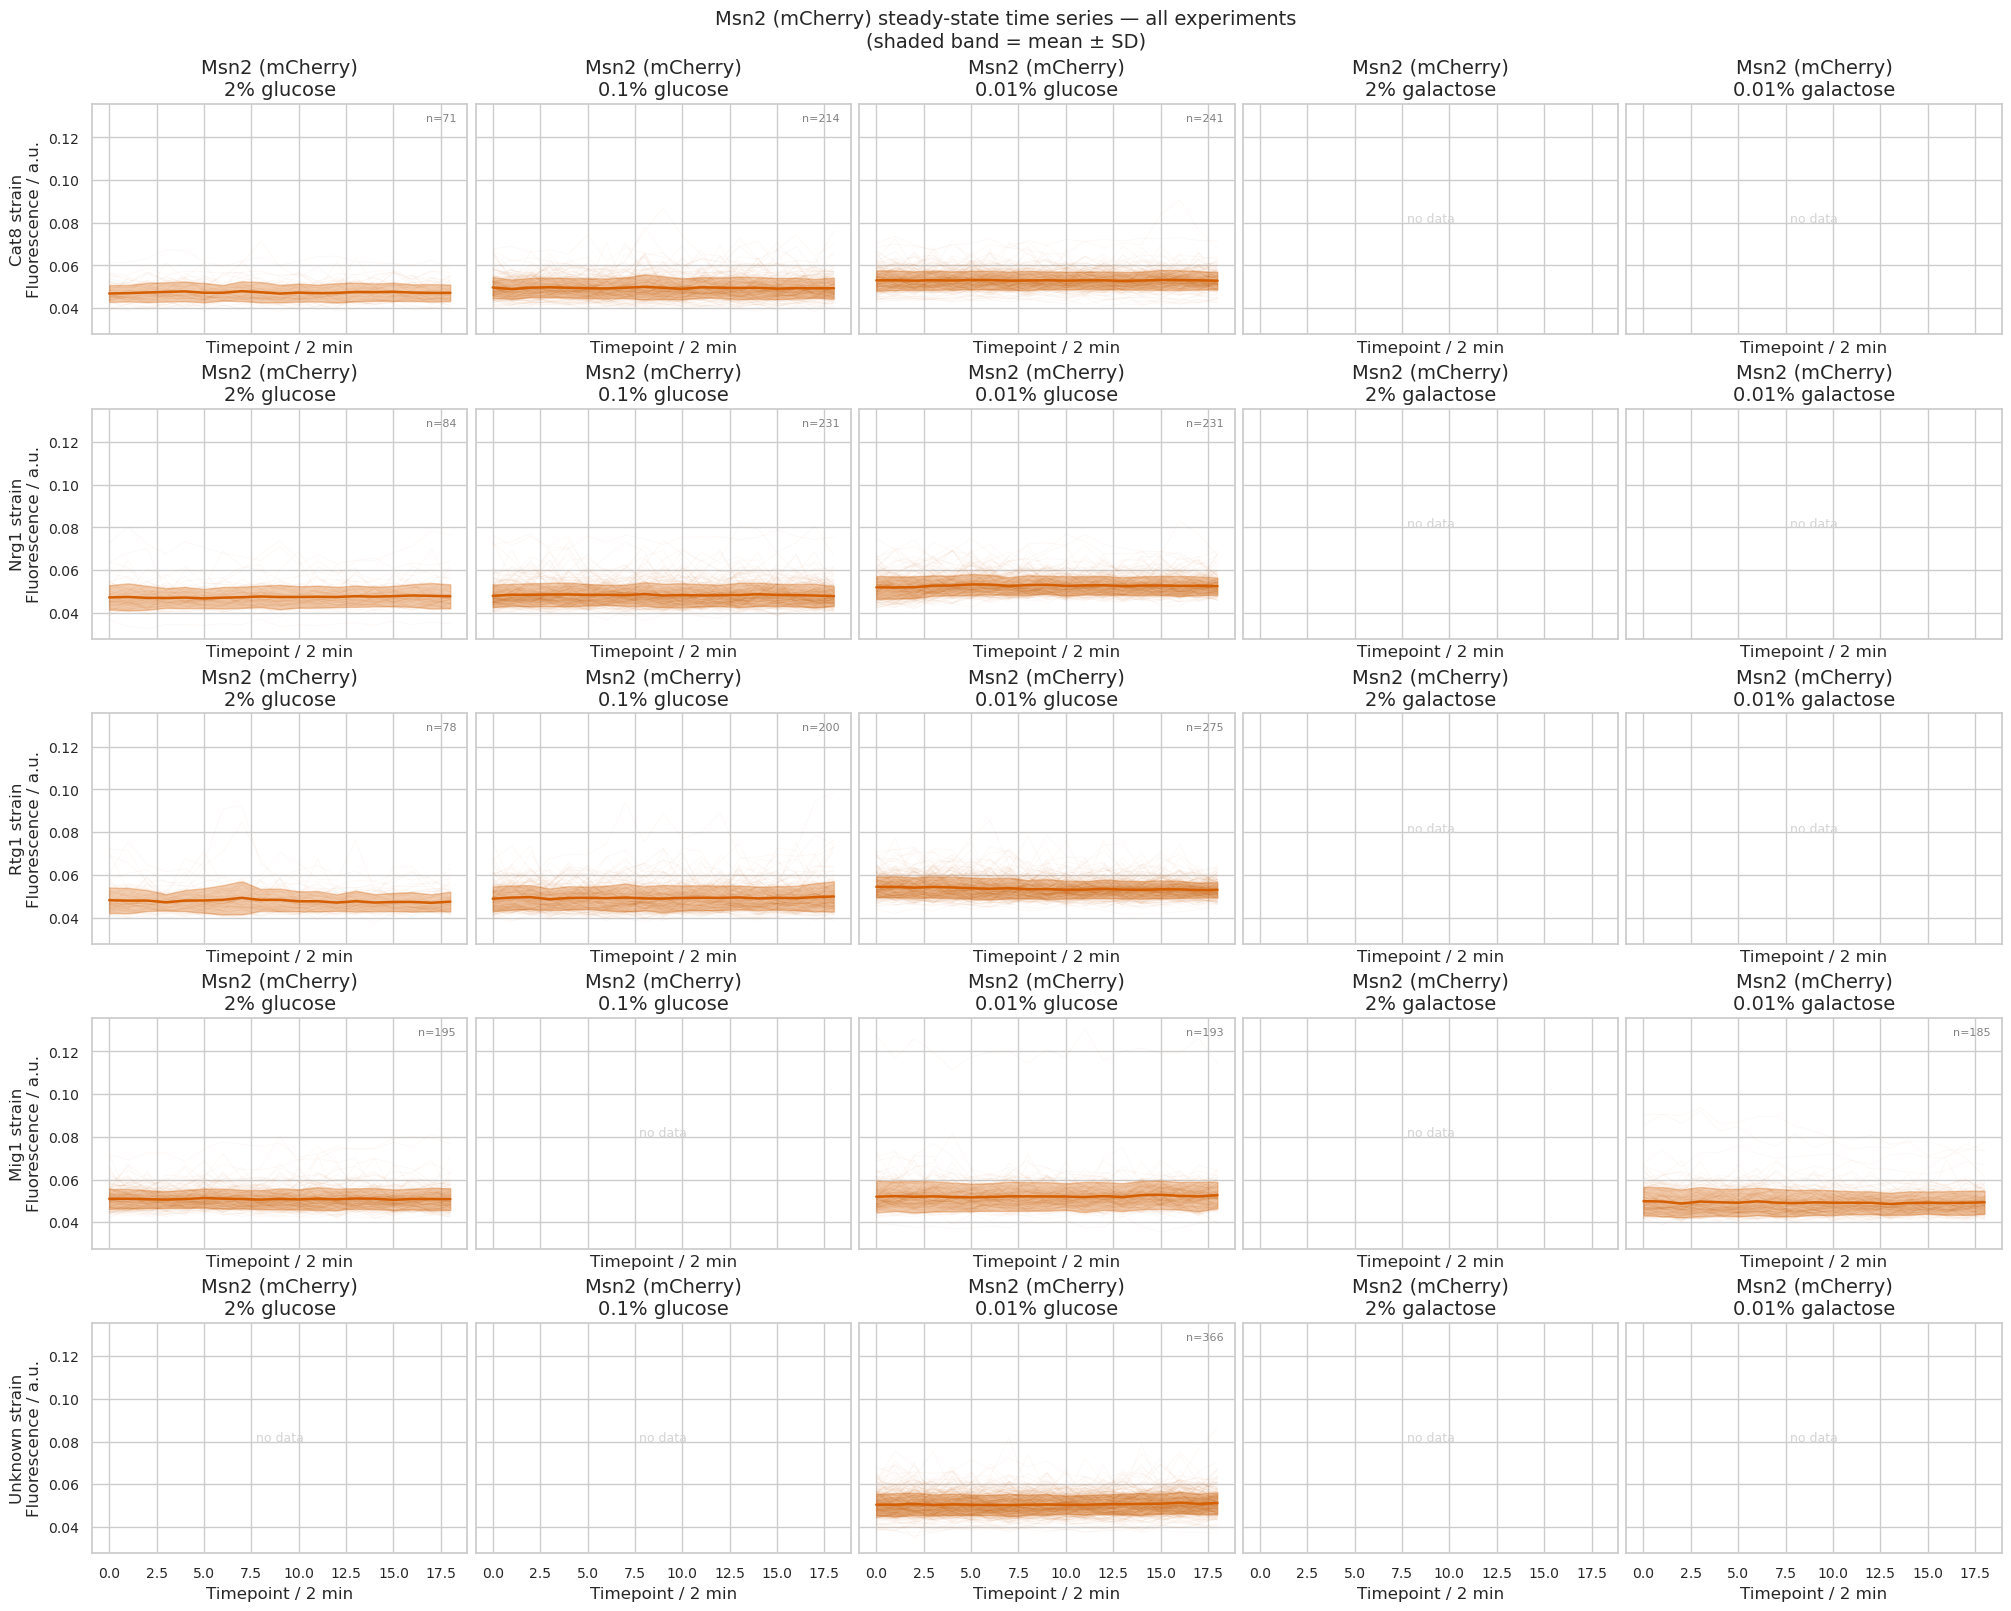

In [14]:
import re as _re

# Group number → GFP TF identity (from OMERO metadata verified above)
GROUP_TO_TF = {
    "1344": "Cat8", "1344_6": "Cat8",
    "1346": "Nrg1", "1346_4": "Nrg1",
    "1347": "Rtg1",
    "900":  "Mig1",
    "756":  "Unknown", "903": "Unknown",
}

palette  = sns.color_palette("colorblind")
ch_color = palette[3]  # reddish — mCherry

# Re-scan CSVs with the same filter logic as the loading cell, but track TF per cell
_plot_X, _plot_y, _plot_tf = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        continue
    if "_mCherry_mCherry_" in csv_path.name:
        continue
    label, _ = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)[:, :min_T]   # truncate to same min_T as X_raw

    m = _re.search(r"_group_(.+?)_mCherry_", csv_path.name)
    group_str = m.group(1) if m else "?"
    tf_name = GROUP_TO_TF.get(group_str, f"group_{group_str}")

    _plot_X.append(ts)
    _plot_y.extend([label] * len(ts))
    _plot_tf.extend([tf_name] * len(ts))

_plot_X  = np.vstack(_plot_X)
_plot_y  = np.array(_plot_y)
_plot_tf = np.array(_plot_tf)

tfs_present  = [t for t in ["Cat8", "Nrg1", "Rtg1", "Mig1", "Unknown"] if t in _plot_tf]
conds_present = sorted(set(_plot_y))
t_axis = np.arange(min_T)

fig, axes = plt.subplots(
    len(tfs_present), len(conds_present),
    figsize=(4 * len(conds_present), 3.2 * len(tfs_present)),
    sharey=True, sharex=True,
    constrained_layout=True,
)
axes = np.array(axes).reshape(len(tfs_present), len(conds_present))

for row, tf in enumerate(tfs_present):
    for col, lbl in enumerate(conds_present):
        ax   = axes[row, col]
        mask = (_plot_tf == tf) & (_plot_y == lbl)
        X_sub = _plot_X[mask]

        if len(X_sub):
            for trace in X_sub:
                ax.plot(t_axis, trace, color=ch_color, alpha=0.05, linewidth=0.5)
            mean = np.nanmean(X_sub, axis=0)
            sd   = np.nanstd(X_sub, axis=0)
            ax.plot(t_axis, mean, color=ch_color, linewidth=1.8)
            ax.fill_between(t_axis, mean - sd, mean + sd, color=ch_color, alpha=0.3)
            ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8, color="gray")
        else:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=9, color="lightgray")

        ax.set_title(f"Msn2 (mCherry)\n{label_names[lbl]}", fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf} strain\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)

fig.suptitle("Msn2 (mCherry) steady-state time series — all experiments\n(shaded band = mean ± SD)",
             fontsize=14)
fig_path = IY021_DIR / "IY021_all_exp_mCherry_catch22_trace_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 2. Preprocessing: NaN Handling, Balancing & Train/Test Split

In [15]:
def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    # IterativeImputer cannot infer a timepoint if every cell is missing there.
    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(
        max_iter=10,
        tol=1e-3,
        initial_strategy="mean",
        random_state=random_state,
    )
    X_imputed = imputer.fit_transform(X_filled)

    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)

X_clean = fill_nans(X_raw)
print(f"NaN remaining after fill: {np.isnan(X_clean).sum()}")

# Balance classes by subsampling to minority class size using seeded RNG
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Minority class count: {min_count} → subsampling all classes to this size")

rng = np.random.default_rng(RANDOM_STATE)
balanced_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])

X_bal = X_clean[balanced_idx]
y_bal = y[balanced_idx]

print(f"\nBalanced dataset: {X_bal.shape[0]} cells × {X_bal.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y_bal == lbl)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bal
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test  class counts: {np.bincount(y_test)}")

NaN remaining after fill: 0
Minority class count: 578 → subsampling all classes to this size

Balanced dataset: 2890 cells × 19 timepoints
  Label 0 (2% glucose): 578
  Label 1 (0.1% glucose): 578
  Label 2 (0.01% glucose): 578
  Label 3 (2% galactose): 578
  Label 4 (0.01% galactose): 578

Train: 2312  |  Test: 578
Train class counts: [462 463 462 462 463]
Test  class counts: [116 115 116 116 115]


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mcherry_catch22_balanced_class_traces.png


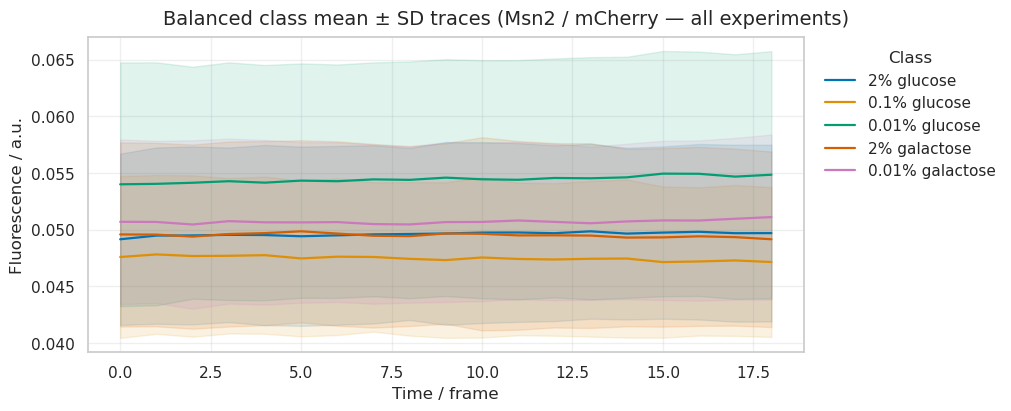

In [16]:
class_names_bal = [label_names[i] for i in sorted(label_names)]
palette = sns.color_palette("colorblind", n_colors=len(class_names_bal))
n_tp = X_bal.shape[1]

fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
for lbl, class_name in enumerate(class_names_bal):
    mask = y_bal == lbl
    mean = X_bal[mask].mean(axis=0)
    sd = X_bal[mask].std(axis=0, ddof=1)
    color = palette[lbl]
    ax.plot(np.arange(n_tp), mean, label=class_name, color=color, linewidth=1.6)
    ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=color, alpha=0.12)

ax.set_xlabel("Time / frame")
ax.set_ylabel("Fluorescence / a.u.")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="Class")
fig.suptitle("Balanced class mean ± SD traces (Msn2 / mCherry — all experiments)", fontsize=14)
fig_path = IY021_DIR / "IY021_all_exp_mcherry_catch22_balanced_class_traces.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()


## 3. Raw SVM (RBF) – Truncated Time Series as Features

In [17]:
print("=== Raw SVM (RBF) ===")
print(f"(using {X_train.shape[1]} timepoints per series)")

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

class_names = [label_names[i] for i in sorted(label_names)]
print(f"Raw SVM Accuracy: {svm_acc:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=class_names))

=== Raw SVM (RBF) ===
(using 19 timepoints per series)


Raw SVM Accuracy: 0.2993

                 precision    recall  f1-score   support

     2% glucose       0.31      0.04      0.08       116
   0.1% glucose       0.26      0.49      0.34       115
  0.01% glucose       0.35      0.49      0.41       116
   2% galactose       0.33      0.23      0.27       116
0.01% galactose       0.28      0.24      0.26       115

       accuracy                           0.30       578
      macro avg       0.31      0.30      0.27       578
   weighted avg       0.31      0.30      0.27       578



## 4. Catch22 + SVM (RBF) – Hand-crafted Features

Catch22 features are length-agnostic, so we extract them from the **full-length series**
(before truncation). This is the key advantage over Raw SVM here.

In [18]:
# Build full-length balanced dataset (variable T per row is OK for Catch22)
# We need to go back to the raw (pre-truncation) balanced rows.
# Strategy: rebuild from all_ts_raw using the same balanced_idx.

# Create a full-length version of X_clean before truncation
all_ts_filled = []
all_y_full = []
for ts in all_ts_raw:
    ts_f = fill_nans(ts)
    all_ts_filled.append(ts_f)
    all_y_full.extend([0] * len(ts_f))  # placeholder, actual y already stored

# Build a list of all series (variable length) in the same order as X_raw / y
# Use object array to handle variable lengths
all_series_list = [row for ts in all_ts_filled for row in ts]

# Apply same balanced_idx
series_bal = [all_series_list[i] for i in balanced_idx]
y_bal_check = y[balanced_idx]
assert np.all(y_bal_check == y_bal)

# Train/test split (same indices as before, applied to full-length series list)
# Re-split using same random state
idx_all = np.arange(len(series_bal))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=y_bal
)
series_train = [series_bal[i] for i in idx_train]
series_test  = [series_bal[i] for i in idx_test]
# y_train / y_test already match (same split logic)

print(f"Full-length series: train={len(series_train)}, test={len(series_test)}")
print(f"Sample series lengths (train): {[len(s) for s in series_train[:5]]}")

Full-length series: train=2312, test=578
Sample series lengths (train): [146, 89, 159, 211, 160]


In [19]:
def extract_catch22(series_list, desc=""):
    """Extract the 22 canonical catch22 features for each series in list."""
    rows = []
    for ts in tqdm(series_list, desc=desc, leave=False):
        out = pycatch22.catch22_all(ts.tolist())
        rows.append(dict(zip(out["names"], out["values"])))
    features = pd.DataFrame(rows)
    features = features.replace([np.inf, -np.inf], np.nan)
    return features


def fit_fill_feature_frame(train_df, test_df):
    """Fill non-finite feature values using medians estimated on the train split."""
    train_df = train_df.copy()
    test_df = test_df.copy()
    medians = train_df.median()
    train_df = train_df.fillna(medians).fillna(0.0)
    test_df = test_df.fillna(medians).fillna(0.0)
    return train_df, test_df


print("Extracting Catch22 features (train)...")
X_train_c22 = extract_catch22(series_train, desc="Train")
print("Extracting Catch22 features (test)...")
X_test_c22  = extract_catch22(series_test,  desc="Test")

X_train_c22, X_test_c22 = fit_fill_feature_frame(X_train_c22, X_test_c22)

print(f"\nCatch22 feature matrix: {X_train_c22.shape[1]} features")

# --- Catch22 + SVM ---
print("\n=== Catch22 + SVM (RBF) ===")

c22_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])

c22_pipe.fit(X_train_c22, y_train)
y_pred_c22 = c22_pipe.predict(X_test_c22)
c22_acc = accuracy_score(y_test, y_pred_c22)

print(f"Catch22 + SVM Accuracy: {c22_acc:.4f}")
print()
class_names = [label_names[i] for i in sorted(label_names)]
print(classification_report(y_test, y_pred_c22, target_names=class_names))

Extracting Catch22 features (train)...


Extracting Catch22 features (test)...



Catch22 feature matrix: 22 features

=== Catch22 + SVM (RBF) ===
Catch22 + SVM Accuracy: 0.4758

                 precision    recall  f1-score   support

     2% glucose       0.40      0.50      0.44       116
   0.1% glucose       0.39      0.38      0.39       115
  0.01% glucose       0.49      0.32      0.39       116
   2% galactose       0.38      0.39      0.38       116
0.01% galactose       0.73      0.79      0.76       115

       accuracy                           0.48       578
      macro avg       0.48      0.48      0.47       578
   weighted avg       0.48      0.48      0.47       578



## 5. Results Comparison

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_catch22_results.csv


,model,accuracy
0,catch22 + SVM (RBF),0.475779
1,Raw SVM (RBF),0.299308


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_svm_vs_catch22.png


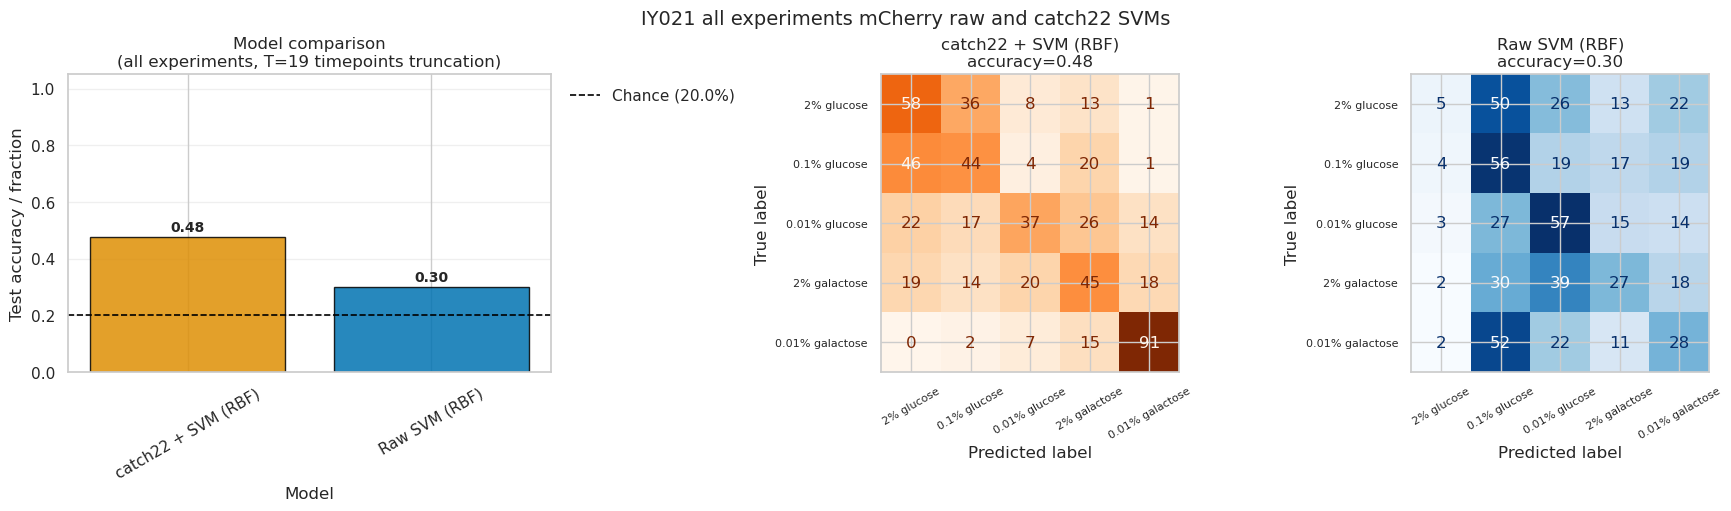


=== Summary ===
  Experiments: ['18446', '18589', '19316', '19330', '19391', '19392', '19394', '19554', '19566', '20213']
  Truncated to 19 timepoints for Raw SVM (global minimum)
  Chance level        : 0.2000
  catch22 + SVM (RBF)   : 0.4758
  Raw SVM (RBF)         : 0.2993
  Winner: catch22 + SVM (RBF) (+0.1765)


In [20]:
class_names = [label_names[i] for i in sorted(label_names)]
chance = 1 / len(label_names)

summary_df = pd.DataFrame([
    {"model": "Raw SVM (RBF)", "accuracy": svm_acc},
    {"model": "catch22 + SVM (RBF)", "accuracy": c22_acc},
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_path = IY021_DIR / "IY021_all_exp_mCherry_catch22_results.csv"
summary_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")
display(summary_df)

predictions = {
    "Raw SVM (RBF)": y_pred_svm,
    "catch22 + SVM (RBF)": y_pred_c22,
}
cmaps = {
    "Raw SVM (RBF)": "Blues",
    "catch22 + SVM (RBF)": "Oranges",
}
colors = {
    "Raw SVM (RBF)": sns.color_palette("colorblind")[0],
    "catch22 + SVM (RBF)": sns.color_palette("colorblind")[1],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
bars = axes[0].bar(
    summary_df["model"],
    summary_df["accuracy"],
    color=[colors[m] for m in summary_df["model"]],
    alpha=0.85,
    edgecolor="black",
)
axes[0].axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Test accuracy / fraction")
axes[0].set_title(f"Model comparison\n(all experiments, T={X_train.shape[1]} timepoints truncation)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, summary_df["accuracy"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

for ax, (_, row) in zip(axes[1:], summary_df.iterrows()):
    model_name = row["model"]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name],
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap=cmaps[model_name],
        xticks_rotation=30,
    )
    ax.set_title(f"{model_name}\naccuracy={row['accuracy']:.2f}")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("IY021 all experiments mCherry raw and catch22 SVMs", fontsize=14)
fig_path = IY021_DIR / "IY021_all_exp_mCherry_svm_vs_catch22.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

print("\n=== Summary ===")
print(f"  Experiments: {sorted(EXPERIMENT_LABELS.keys())}")
print(f"  Truncated to {X_train.shape[1]} timepoints for Raw SVM (global minimum)")
print(f"  Chance level        : {chance:.4f}")
for _, row in summary_df.iterrows():
    print(f"  {row['model']:<22s}: {row['accuracy']:.4f}")
print(f"  Winner: {summary_df.iloc[0]['model']} (+{summary_df.iloc[0]['accuracy'] - summary_df.iloc[-1]['accuracy']:.4f})")